# Forest through the Trees: reproduction of AP-Trees

Research Seminar: Data Analysis in Finance

**Paper:** Bryzgalova, S., Pelger, M., Zhu, J. (2025). Forest through the Trees: Building Cross-Sections of Stock Returns. *The Journal of Finance*, 80(5), 2447–2506.

**Group 7:** Arsentyev Arseniy, Grebennikova Polina, Kantemirova Elizaveta, Pushkarev Vladislav

We rebuild the main example of the paper, AP-Trees on size, operating profitability and investment, in Python from the text of the paper and its appendix, and compare it with triple-sorted portfolios.

## 1. Setup

Libraries, paths and the sample split of the paper: 240 months for training, 120 for validation, the rest for the test.

In [1]:
from pathlib import Path
import io
import itertools
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import lars_path_gram

ROOT = Path.cwd()
DATA = ROOT / "data"
FIG = ROOT / "figures"
DATA.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

CHARS = ["LME", "OP", "Investment"]
NAMES = ["Size", "OP", "Inv"]
N_TRAIN, N_VALID = 240, 120
LAMBDA0 = np.round(np.arange(0, 0.91, 0.05), 2)
LAMBDA2 = 0.1 ** np.arange(5, 8.01, 0.25)
KS = range(5, 51)

NAVY, ORANGE, GREY, LIGHT = "#0F2C68", "#EB8C3C", "#A0A0A0", "#9DB2D9"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})

## 2. Data

The authors share the stock-level data for this cross-section on Markus Pelger's website ("Data for Code", about 1 GB). Because of the WRDS licence they added random noise to returns and market caps, so our numbers cannot be exactly the numbers of the paper. The Fama-French factors come from Kenneth French's data library. The first run downloads everything (5–10 minutes).

In [2]:
DATA_URL = "https://www.dropbox.com/scl/fo/z5r2qm0lsi1rnc3sop6mx/h?rlkey=zis71edhnmygr3a4ftqzeupco&dl=1"
FRENCH = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
WANTED = ["data_chunk_files_quantile/LME_OP_Investment/", "factor/",
          "tree_portfolio_quantile/LME_OP_Investment/level_all_excess_combined_filtered.csv",
          "TreeGridSearch/LME_OP_Investment/SR_N.csv", "TreeGridSearch/LME_OP_Investment/Selected_Ports_10.csv"]


def download(url, path):
    if not path.exists():
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open(path, "wb") as f:
            while chunk := r.read(1 << 22):
                f.write(chunk)
    return path


authors = DATA / "authors"
if not authors.exists():
    with zipfile.ZipFile(download(DATA_URL, DATA / "Data.zip")) as z:
        for name in z.namelist():
            clean = name.lstrip("/")
            if not clean.endswith("/") and any(clean.startswith(w) for w in WANTED):
                target = authors / clean
                target.parent.mkdir(parents=True, exist_ok=True)
                target.write_bytes(z.read(name))


def french_table(name):
    path = DATA / name.replace("_CSV.zip", ".csv")
    if not path.exists():
        req = urllib.request.Request(FRENCH + name, headers={"User-Agent": "Mozilla/5.0"})
        z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(req).read()))
        path.write_bytes(z.read(z.namelist()[0]))
    lines = path.read_text(encoding="latin-1").splitlines()
    start = next(i for i, l in enumerate(lines) if l.strip().startswith(","))
    rows = []
    for l in lines[start + 1:]:
        parts = [p.strip() for p in l.split(",")]
        if len(parts[0]) != 6 or not parts[0].isdigit():
            break
        rows.append(parts)
    table = pd.DataFrame(rows, columns=["month"] + [c.strip() for c in lines[start].split(",")[1:]]).astype(float)
    return table.astype({"month": int}).set_index("month") / 100


ff3 = french_table("F-F_Research_Data_Factors_CSV.zip")
ff5 = french_table("F-F_Research_Data_5_Factors_2x3_CSV.zip")

In [3]:
folder = authors / "data_chunk_files_quantile" / "LME_OP_Investment"
panel = pd.concat([pd.read_csv(folder / f"y{y}.csv") for y in range(1964, 2017)], ignore_index=True)
print(panel.shape)
panel.head()

(2551309, 9)


,yy,mm,date,permno,ret,LME,OP,Investment,size
0,1964,1,19630131,10006,0.029009,0.776637,0.278626,0.987273,112.056258
1,1964,1,19630131,10014,0.013580,0.351906,0.250000,0.980000,11.948442
2,1964,1,19630131,10102,0.085040,0.874878,0.454198,0.916364,272.007057
3,1964,1,19630131,10137,0.062883,0.922287,0.883588,0.372727,455.200294
4,1964,1,19630131,10153,0.119149,0.796188,0.036260,0.076364,131.011633


The files have two time columns: `yy`/`mm` and `date`. While checking the data we noticed that the file `y1964.csv` contains dates from 1963. To find the real month we compare the value-weighted return of all stocks with the market return.

In [4]:
def vw_return(d):
    return np.average(d["ret"], weights=d["size"])


panel["month_label"] = panel["yy"] * 100 + panel["mm"]
panel["month"] = panel["date"] // 100
market = ff3["Mkt-RF"] + ff3["RF"]

by_label = panel.groupby("month_label")[["ret", "size"]].apply(vw_return)
by_date = panel.groupby("month")[["ret", "size"]].apply(vw_return)
print("correlation with the market, month from yy/mm:", round(by_label.corr(market), 3))
print("correlation with the market, month from date: ", round(by_date.corr(market), 3))

correlation with the market, month from yy/mm: 0.031
correlation with the market, month from date:  0.992


So `date` is the real month and `yy` is one year ahead. Inside a row the timing is fine (`size` is last month's market cap and `ret` is this month's return), so we simply use `date`. Our sample is 1963–2015 and the test period is 1993–2015, with the same lengths as in the paper (1994–2016).

In [5]:
months = sorted(panel["month"].unique())
T = len(months)
panel["t"] = panel["month"].map({m: i for i, m in enumerate(months)})
rf = ff3.loc[months, "RF"].values
factors = pd.read_csv(authors / "factor" / "tradable_factors.csv", index_col=0).reindex(months)
TEST = slice(N_TRAIN + N_VALID, T)
print(T, "months:", months[0], "-", months[-1], "| test:", months[TEST][0], "-", months[TEST][-1])

636 months: 196301 - 201512 | test: 199301 - 201512


## 3. AP-Tree portfolios

A tree splits the stocks at the median of one characteristic, then each half at the median of the next one, four times. With 3 characteristics there are 3⁴ = 81 split orders. Every node of a tree, also the intermediate ones, is a value-weighted portfolio. A node that appears in several trees is kept once, and like the paper we drop depth-4 nodes that use only one characteristic.

The id of a node is written like in the paper: `3111.11111` means split order Inv, Size, Size, Size and path 1-1-1-1 (1 = lower half, 2 = upper half; the first 1 is the root).

In [6]:
def median_split(x, groups):
    order = np.lexsort((x, groups))
    g = groups[order]
    counts = np.bincount(g)
    rank = np.arange(len(x)) - (np.cumsum(counts) - counts)[g]
    upper = np.zeros(len(x), dtype=int)
    upper[order] = 2 * rank >= counts[g]
    return upper


def node_id(prefix, code):
    d = len(prefix)
    order = "".join(str(c + 1) for c in prefix).ljust(4, "1")
    path = "".join(str(((code >> (d - 1 - i)) & 1) + 1) for i in range(d))
    return order + ".1" + path


def describe(pid):
    order, path = pid.split(".")
    d = len(path) - 1
    lo, hi = [0.0] * 3, [1.0] * 3
    for c, b in zip(order[:d], path[1:]):
        c = int(c) - 1
        mid = (lo[c] + hi[c]) / 2
        if b == "1":
            hi[c] = mid
        else:
            lo[c] = mid
    used = dict.fromkeys(int(c) - 1 for c in order[:d])
    return ", ".join(f"{NAMES[c]} {lo[c] * 100:g}-{hi[c] * 100:g}%" for c in used) or "Market"


prefixes = [p for d in range(5) for p in itertools.product(range(3), repeat=d) if not (d == 4 and len(set(p)) == 1)]
columns = [node_id(p, c) for p in prefixes for c in range(2 ** len(p))]
depth = np.array([len(c.split(".")[1]) - 1 for c in columns])
print(len(columns), "portfolios")
print(columns[:7], "...")
print("1221.1111 =", describe("1221.1111"))

1507 portfolios
['1111.1', '1111.11', '1111.12', '2111.11', '2111.12', '3111.11', '3111.12'] ...
1221.1111 = Size 0-50%, OP 0-25%


In [7]:
start = time.time()
tree_ret = np.full((T, len(columns)), np.nan)
for t, m in panel.groupby("t"):
    r, w, X = m["ret"].values, m["size"].values, m[CHARS].values
    codes = {(): np.zeros(len(r), dtype=int)}
    col = 0
    for p in prefixes:
        if p:
            codes[p] = 2 * codes[p[:-1]] + median_split(X[:, p[-1]], codes[p[:-1]])
        k = 2 ** len(p)
        tree_ret[t, col:col + k] = np.bincount(codes[p], w * r, k) / np.bincount(codes[p], w, k)
        col += k

trees = pd.DataFrame(tree_ret - rf[:, None], index=months, columns=columns)
print(f"{time.time() - start:.0f} s, missing values: {trees.isna().sum().sum()}")
print("correlation of the root node with the market:", round(np.corrcoef(trees["1111.1"], ff3.loc[months, "Mkt-RF"])[0, 1], 3))

30 s, missing values: 0
correlation of the root node with the market: 0.992


The authors ship their own tree portfolios built from the same noisy files. After adding back the risk-free rate (they subtract it for the shifted months) the two sets should be the same.

In [8]:
theirs = pd.read_csv(authors / "tree_portfolio_quantile" / "LME_OP_Investment" / "level_all_excess_combined_filtered.csv")
theirs.columns = [c[1:] for c in theirs.columns]
their_rf = pd.read_csv(authors / "factor" / "rf_factor.csv", header=None)[0].values / 100

diff = (theirs[columns].values + their_rf[:, None]) - (trees.values + rf[:, None])
print("same 1507 portfolios:", sorted(theirs.columns) == sorted(columns))
print("largest difference:", np.abs(diff).max())

same 1507 portfolios: True
largest difference: 1.0547118733938987e-15


## 4. Benchmark: triple sorts

TS(32) uses 2 size groups × 4 × 4, TS(64) uses 4 × 4 × 4. The sorts are independent and value-weighted; like in the authors' code, empty cells get a return of 0.

In [9]:
def ntile(x, q):
    n = len(x)
    rank = np.empty(n, dtype=int)
    rank[np.argsort(x, kind="stable")] = np.arange(1, n + 1)
    big, small = -(-n // q), n // q
    cut = big * (n % q)
    return np.where(rank <= cut, (rank - 1) // big, (rank - cut - 1) // max(small, 1) + n % q)


def triple_sort(groups):
    cells = list(itertools.product(*[range(g) for g in groups]))
    n = len(cells)
    out = np.full((T, n), np.nan)
    for t, m in panel.groupby("t"):
        code = np.zeros(len(m), dtype=int)
        for c, g in zip(CHARS, groups):
            code = code * g + ntile(m[c].values, g)
        with np.errstate(invalid="ignore"):
            out[t] = np.bincount(code, m["size"] * m["ret"], n) / np.bincount(code, m["size"], n)
    names = ["".join(str(i + 1) for i in cell) for cell in cells]
    return pd.DataFrame(out - rf[:, None], index=months, columns=names).fillna(0)


ts32 = triple_sort((2, 4, 4))
ts64 = triple_sort((4, 4, 4))
print(ts32.shape, ts64.shape)

(636, 32) (636, 64)


## 5. AP-Pruning

Definition 1 of the paper and its Internet Appendix:

- returns of a node at depth $d$ are divided by $\sqrt{2^d}$, so big diversified nodes are preferred;
- means are shrunk toward their cross-sectional average: $\mu + \lambda_0 \bar\mu \mathbf{1}$;
- the covariance gets a ridge: $\Sigma + \lambda_2 I$;
- a LASSO penalty $\lambda_1$ keeps only K portfolios.

This is a LASSO regression on an augmented design $X = [\Sigma^{1/2}; \sqrt{\lambda_2} I]$, $y = [\Sigma^{-1/2}(\mu + \lambda_0 \bar\mu \mathbf{1}); 0]$, which we solve with LARS. LARS only needs $X'X = \Sigma + \lambda_2 I$ and $X'y$, so we never build X. For each K we take the first point on the LARS path with K non-zero weights.

In [10]:
def moments(R):
    vals, vecs = np.linalg.eigh(np.cov(R, rowvar=False))
    keep = vals > 1e-10
    return R.mean(axis=0), (vecs[:, keep] * vals[keep]) @ vecs[:, keep].T, vecs[:, keep]


def lars_weights(mu, sigma, vecs, lambda0, lambda2, scale, k_max=64):
    target = vecs @ (vecs.T @ (mu + lambda0 * mu.mean()))
    _, _, path = lars_path_gram(target, sigma + lambda2 * np.eye(len(mu)), n_samples=1, max_iter=250, method="lasso")
    weights = {}
    for b in path.T:
        k = int((b != 0).sum())
        if 1 <= k <= k_max and k not in weights:
            w = b * scale
            weights[k] = w / abs(w.sum())
    return weights


def sharpe(x):
    return x.mean() / x.std(ddof=1)

Check on the authors' demo setting ($\lambda_0 = 0.15$, $\lambda_2 = 10^{-8}$, K = 10) with their own portfolios. Their R code gives validation SR 0.715 and test SR 0.589.

In [11]:
R = theirs.values
scale = 1 / np.sqrt(2.0 ** np.array([len(c.split(".")[1]) - 1 for c in theirs.columns]))
w_valid = lars_weights(*moments(R[:N_TRAIN] * scale), 0.15, 1e-8, scale)[10]
w_test = lars_weights(*moments(R[:N_TRAIN + N_VALID] * scale), 0.15, 1e-8, scale)[10]
their_pick = pd.read_csv(authors / "TreeGridSearch" / "LME_OP_Investment" / "Selected_Ports_10.csv").columns

print("validation SR:", round(sharpe(R[N_TRAIN:N_TRAIN + N_VALID] @ w_valid), 3))
print("test SR:", round(sharpe(R[TEST] @ w_test), 3))
print("same 10 portfolios as the authors:", sorted(theirs.columns[w_test != 0]) == sorted(c[1:] for c in their_pick))

validation SR: 0.715
test SR: 0.589
same 10 portfolios as the authors: True


## 6. Tuning on the validation sample

The grid of the paper: 19 values of $\lambda_0$ × 13 values of $\lambda_2$, and the LARS path gives all K at once. The validation SR (fit on 1963–1982, evaluated on 1983–1992) chooses $(\lambda_0, \lambda_2)$ for each K. Then the weights are estimated again on 1963–1992 and evaluated on the test sample. The same procedure is used for the triple sorts. Takes about 2 minutes.

In [12]:
def grid_search(R, depth, ks):
    R = np.asarray(R)
    scale = 1 / np.sqrt(2.0 ** np.asarray(depth))
    m_train = moments(R[:N_TRAIN] * scale)
    m_full = moments(R[:N_TRAIN + N_VALID] * scale)
    rows = []
    for l0 in LAMBDA0:
        for l2 in LAMBDA2:
            w_train = lars_weights(*m_train, l0, l2, scale)
            w_full = lars_weights(*m_full, l0, l2, scale)
            for k in ks:
                if k in w_train and k in w_full:
                    rows.append({"lambda0": l0, "lambda2": l2, "K": k,
                                 "valid_SR": sharpe(R[N_TRAIN:N_TRAIN + N_VALID] @ w_train[k]),
                                 "test_SR": sharpe(R[TEST] @ w_full[k])})
    return pd.DataFrame(rows)


def pick(grid, k):
    g = grid[grid["K"] == k]
    return g.loc[g["valid_SR"].idxmax()]


def final_weights(R, depth, best):
    R = np.asarray(R)
    scale = 1 / np.sqrt(2.0 ** np.asarray(depth))
    return lars_weights(*moments(R[:N_TRAIN + N_VALID] * scale), best["lambda0"], best["lambda2"], scale)[int(best["K"])]


start = time.time()
grid_trees = grid_search(trees, depth, KS)
grid_ts32 = grid_search(ts32, np.zeros(32), [32])
grid_ts64 = grid_search(ts64, np.zeros(64), [64])
print(f"{time.time() - start:.0f} s")

38 s


## 7. Main result (Table I of the paper)

For every set of basis assets we report the test Sharpe ratio of the SDF, the alpha of the SDF against the Fama-French five factors (the SDF is scaled to a mean of 1, so alpha is the share of its mean return that the factors do not explain) and the cross-sectional $R^2$ of FF5 on the basis assets, $1 - \frac{N}{N-k}\frac{\sum \alpha_i^2}{\sum \bar R_i^2}$. The factors are the ones in the authors' factor file.

In [13]:
FF5 = ["Mkt-RF", "LME", "BEME", "OP", "Investment"]
F_test = factors[FF5].values[TEST]


def sdf_alpha(sdf, F):
    fit = sm.OLS(sdf / sdf.mean(), sm.add_constant(F)).fit()
    return fit.params[0], fit.tvalues[0]


def xs_r2(ports, F):
    X = sm.add_constant(F)
    alphas = np.linalg.lstsq(X, ports, rcond=None)[0][0]
    n, k = ports.shape[1], X.shape[1]
    return 1 - (alphas ** 2).sum() / (ports.mean(axis=0) ** 2).sum() * n / (n - k)


setups = [("AP-Trees (10)", trees, depth, grid_trees, 10), ("AP-Trees (40)", trees, depth, grid_trees, 40),
          ("TS (32)", ts32, np.zeros(32), grid_ts32, 32), ("TS (64)", ts64, np.zeros(64), grid_ts64, 64)]
rows, sdfs, chosen = [], {}, {}
for name, R, d, grid, k in setups:
    best = pick(grid, k)
    w = final_weights(R, d, best)
    sdfs[name] = R.values[TEST] @ w
    chosen[name] = pd.Series(w, index=R.columns)[w != 0]
    a, t = sdf_alpha(sdfs[name], F_test)
    rows.append({"basis": name, "lambda0": best["lambda0"], "lambda2": best["lambda2"],
                 "valid SR": best["valid_SR"], "test SR": sharpe(sdfs[name]), "alpha FF5": a, "t": t,
                 "XS-R2 FF5": xs_r2(R.values[TEST][:, w != 0], F_test)})

table1 = pd.DataFrame(rows).set_index("basis")
table1["paper SR"] = [0.65, 0.69, 0.51, 0.53]
table1["paper alpha FF5"] = [0.81, 0.76, 0.47, 0.61]
table1["paper XS-R2 FF5"] = [0.11, 0.64, 0.91, 0.90]
table1.round(3)

,lambda0,lambda2,valid SR,test SR,alpha FF5,t,XS-R2 FF5,paper SR,paper alpha FF5,paper XS-R2 FF5
basis,,,,,,,,,,
AP-Trees (10),0.75,0.0,0.777,0.595,0.710,7.334,0.139,0.65,0.81,0.11
AP-Trees (40),0.60,0.0,1.080,0.610,0.718,8.991,0.720,0.69,0.76,0.64
TS (32),0.90,0.0,0.610,0.471,0.495,5.058,0.906,0.51,0.47,0.91
TS (64),0.90,0.0,0.521,0.538,0.666,7.634,0.881,0.53,0.61,0.90


In [14]:
their_sr = pd.read_csv(authors / "TreeGridSearch" / "LME_OP_Investment" / "SR_N.csv").values
print("authors' own run on the public data, test SR at K = 10:", round(their_sr[2, 5], 3))

authors' own run on the public data, test SR at K = 10: 0.6


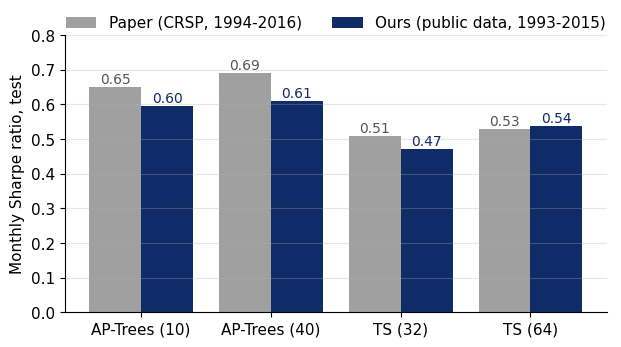

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(4)
ax.bar(x - 0.2, table1["paper SR"], 0.4, color=GREY, label="Paper (CRSP, 1994-2016)")
ax.bar(x + 0.2, table1["test SR"], 0.4, color=NAVY, label="Ours (public data, 1993-2015)")
for xi, (p, o) in enumerate(zip(table1["paper SR"], table1["test SR"])):
    ax.text(xi - 0.2, p + 0.01, f"{p:.2f}", ha="center", fontsize=10, color="#555555")
    ax.text(xi + 0.2, o + 0.01, f"{o:.2f}", ha="center", fontsize=10, color=NAVY)
ax.set_xticks(x, table1.index)
ax.set_ylabel("Monthly Sharpe ratio, test")
ax.set_ylim(0, 0.8)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.12))
fig.savefig(FIG / "sr_paper_vs_ours.png")
plt.show()

Same ranking as in the paper: AP-Trees have a higher Sharpe ratio than both triple sorts, and FF5 explains most of the sorted portfolios but only a small part of the AP-Tree portfolios. Our AP-Tree Sharpe ratios are lower than in the paper (0.60 vs 0.65), but the authors' own run on the same public data also gives 0.60, so the gap comes from the noise in the data and not from our code.

## 8. How many portfolios do we need? (Figure 10)

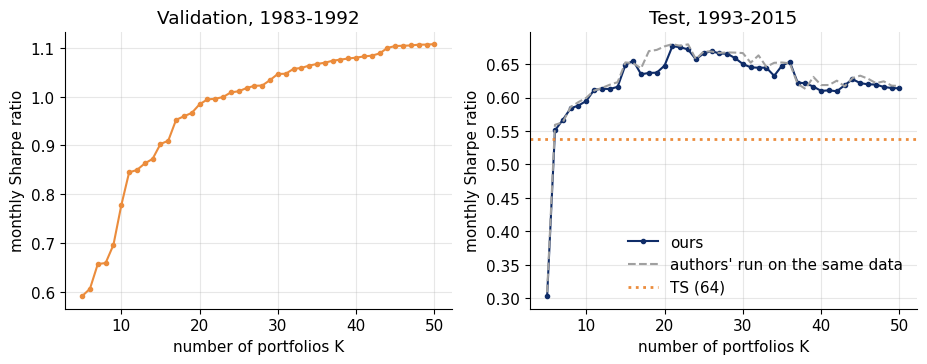

best test SR: 0.677 at K = 21


In [16]:
by_k = pd.DataFrame([pick(grid_trees, k) for k in KS])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(by_k["K"], by_k["valid_SR"], color=ORANGE, marker="o", ms=3)
axes[0].set_title("Validation, 1983-1992")
axes[1].plot(by_k["K"], by_k["test_SR"], color=NAVY, marker="o", ms=3, label="ours")
axes[1].plot(by_k["K"], their_sr[2], color=GREY, ls="--", label="authors' run on the same data")
axes[1].axhline(table1.loc["TS (64)", "test SR"], color=ORANGE, ls=":", lw=2, label="TS (64)")
axes[1].set_title("Test, 1993-2015")
axes[1].legend(frameon=False, loc="lower right")
for ax in axes:
    ax.set_xlabel("number of portfolios K")
    ax.set_ylabel("monthly Sharpe ratio")
fig.savefig(FIG / "sr_vs_k.png")
plt.show()
print("best test SR:", round(by_k["test_SR"].max(), 3), "at K =", int(by_k.loc[by_k["test_SR"].idxmax(), "K"]))

The same test curve alone, drawn like panel C of Figure 10 in the paper, to put them side by side in the slides.

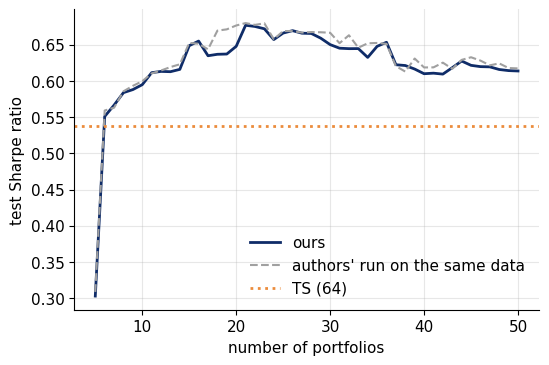

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.9))
ax.plot(by_k["K"], by_k["test_SR"], color=NAVY, lw=2, label="ours")
ax.plot(by_k["K"], their_sr[2], color=GREY, ls="--", label="authors' run on the same data")
ax.axhline(table1.loc["TS (64)", "test SR"], color=ORANGE, ls=":", lw=2, label="TS (64)")
ax.set_xlabel("number of portfolios")
ax.set_ylabel("test Sharpe ratio")
ax.legend(frameon=False, loc="lower right")
fig.savefig(FIG / "sr_vs_k_test.png")
plt.show()

Like in the paper, the validation SR keeps growing with K, but the test SR stops growing after about 15–20 portfolios. Our curve lies on top of the curve from the authors' own run.

## 9. Which portfolios are selected? (Table II)

The 10 AP-Tree portfolios, their SDF weights and their own FF5 alphas on the test sample (% per month). `in paper` marks portfolios that are also in Table II of the paper.

In [18]:
PAPER_IDS = ["1111.1", "1111.121", "3111.11", "3111.11111", "3211.1121",
             "1221.1111", "2221.11111", "3331.12221", "2122.11111", "3133.12122"]

rows = []
for pid, w in chosen["AP-Trees (10)"].items():
    fit = sm.OLS(trees[pid].values[TEST], sm.add_constant(F_test)).fit()
    rows.append({"id": pid, "portfolio": describe(pid), "stocks": f"{100 / 2 ** (len(pid) - 6):g}%",
                 "SDF weight": w, "alpha FF5, %": 100 * fit.params[0], "t": fit.tvalues[0], "in paper": pid in PAPER_IDS})
table2 = pd.DataFrame(rows).set_index("id").sort_values("SDF weight", ascending=False)
table2.round(2)

,portfolio,stocks,SDF weight,"alpha FF5, %",t,in paper
id,,,,,,
3111.11111,"Inv 0-50%, Size 0-12.5%",6.25%,1.05,1.40,5.72,True
3231.1121,"Inv 0-25%, OP 50-100%",12.5%,0.71,-0.21,-2.67,False
1311.11111,"Size 0-12.5%, Inv 0-50%",6.25%,0.24,1.29,5.12,False
2322.12121,"OP 75-87.5%, Inv 0-50%",6.25%,0.16,0.07,0.66,False
3222.11222,"Inv 0-50%, OP 87.5-100%",6.25%,0.13,-0.04,-0.39,False
1211.11111,"Size 0-12.5%, OP 0-50%",6.25%,0.11,1.06,4.32,False
3211.1121,"Inv 0-50%, OP 50-100%, Size 0-50%",12.5%,0.08,0.07,1.02,True
1221.1111,"Size 0-50%, OP 0-25%",12.5%,-0.02,-0.31,-2.90,True
3331.12221,"Inv 87.5-100%, Size 0-50%",6.25%,-0.64,-0.63,-4.89,True


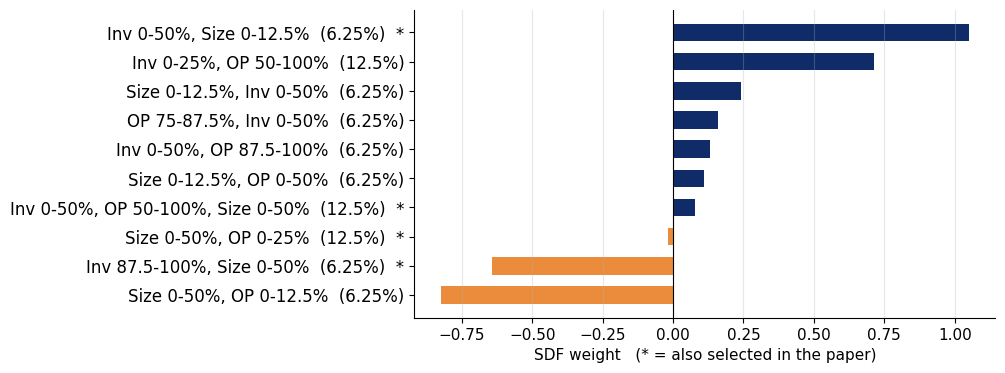

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4))
y = np.arange(len(table2))[::-1]
colors = [NAVY if w > 0 else ORANGE for w in table2["SDF weight"]]
ax.barh(y, table2["SDF weight"], color=colors, height=0.6)
labels = [f"{d}  ({s})" + ("  *" if p else "") for d, s, p in zip(table2["portfolio"], table2["stocks"], table2["in paper"])]
ax.set_yticks(y, labels)
ax.tick_params(axis="y", labelsize=12)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SDF weight   (* = also selected in the paper)")
ax.grid(axis="y", visible=False)
fig.savefig(FIG / "sdf_weights.png")
plt.show()

## 10. Do interactions matter? (Figure 8)

We keep only the nodes that split on a single characteristic (43 portfolios, no interactions) and run the same pruning.

43 portfolios, test SR: 0.271


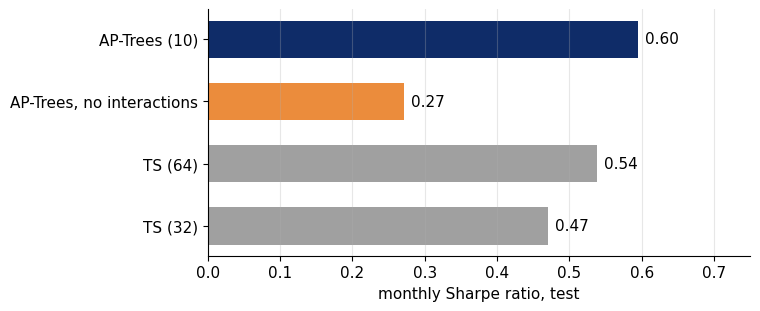

In [20]:
single = [c for c in columns if len(set(c.split(".")[0][:len(c) - 6])) <= 1]
grid_single = grid_search(trees[single], depth[[columns.index(c) for c in single]], [10])
best = pick(grid_single, 10)
sdfs["AP-Trees, no interactions"] = trees[single].values[TEST] @ final_weights(trees[single], depth[[columns.index(c) for c in single]], best)
print(len(single), "portfolios, test SR:", round(sharpe(sdfs["AP-Trees, no interactions"]), 3))

names = ["AP-Trees (10)", "AP-Trees, no interactions", "TS (64)", "TS (32)"]
values = [sharpe(sdfs[n]) for n in names]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(names[::-1], values[::-1], color=[GREY, GREY, ORANGE, NAVY], height=0.6)
for i, v in enumerate(values[::-1]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center")
ax.set_xlabel("monthly Sharpe ratio, test")
ax.set_xlim(0, 0.75)
ax.grid(axis="y", visible=False)
fig.savefig(FIG / "interactions.png")
plt.show()

Without interaction nodes the Sharpe ratio falls by more than half, below the triple sorts. The paper finds the same (about half).

## 11. Our checks

### 11.1 Is the difference with triple sorts significant?

The paper does not report standard errors for the differences in Sharpe ratios. We use a circular block bootstrap of the test months (blocks of 6 months, 10,000 draws), resampling both SDFs together.

In [21]:
def bootstrap_diff(a, b, block=6, n=10000, seed=0):
    rng = np.random.default_rng(seed)
    out = np.empty(n)
    for i in range(n):
        starts = rng.integers(0, len(a), len(a) // block + 1)
        idx = (starts[:, None] + np.arange(block)).ravel()[:len(a)] % len(a)
        out[i] = sharpe(a[idx]) - sharpe(b[idx])
    return out


rows = []
for a, b in [("AP-Trees (10)", "TS (64)"), ("AP-Trees (10)", "TS (32)"), ("AP-Trees (40)", "TS (64)"),
             ("AP-Trees (10)", "AP-Trees, no interactions")]:
    d = bootstrap_diff(sdfs[a], sdfs[b])
    if a == "AP-Trees (10)" and b == "TS (64)":
        main_draws = d
    rows.append({"A": a, "B": b, "SR difference": sharpe(sdfs[a]) - sharpe(sdfs[b]),
                 "95% CI low": np.percentile(d, 2.5), "95% CI high": np.percentile(d, 97.5), "share of draws <= 0": (d <= 0).mean()})
pd.DataFrame(rows).round(2)

,A,B,SR difference,95% CI low,95% CI high,share of draws <= 0
0,AP-Trees (10),TS (64),0.06,-0.11,0.23,0.25
1,AP-Trees (10),TS (32),0.12,-0.04,0.29,0.07
2,AP-Trees (40),TS (64),0.07,-0.04,0.19,0.11
3,AP-Trees (10),"AP-Trees, no interactions",0.32,0.23,0.43,0.00


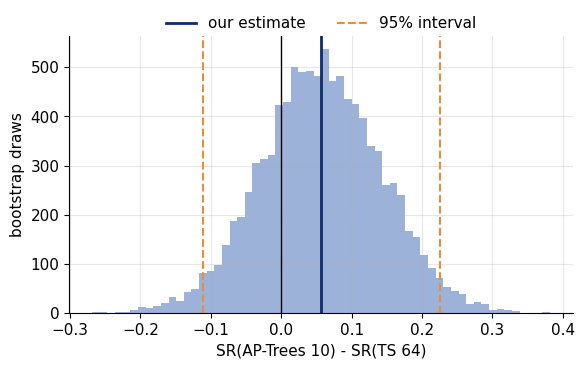

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(main_draws, bins=60, color=LIGHT)
ax.axvline(0, color="black", lw=1)
ax.axvline(sharpe(sdfs["AP-Trees (10)"]) - sharpe(sdfs["TS (64)"]), color=NAVY, lw=2, label="our estimate")
lo, hi = np.percentile(main_draws, [2.5, 97.5])
ax.axvline(lo, color=ORANGE, ls="--")
ax.axvline(hi, color=ORANGE, ls="--", label="95% interval")
ax.set_xlabel("SR(AP-Trees 10) - SR(TS 64)")
ax.set_ylabel("bootstrap draws")
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.12))
fig.savefig(FIG / "bootstrap.png")
plt.show()

The 95% interval for AP-Trees (10) minus TS (64) contains zero: in one cross-section and 23 years of test data the advantage over good triple sorts is not statistically significant. The advantage over trees without interactions is.

### 11.2 Official Fama-French factors

The "FF5" of the paper are the authors' own long-short portfolios. We repeat the SDF alpha with Kenneth French's official factors.

In [23]:
official = ff5.reindex(months)[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].values[TEST]
print("correlation of the authors' factors with the official ones:")
print(factors.iloc[12:][["LME", "BEME", "OP", "Investment"]].corrwith(
    ff5.reindex(months).iloc[12:][["SMB", "HML", "RMW", "CMA"]].set_axis(["LME", "BEME", "OP", "Investment"], axis=1)).round(2).to_dict())

rows = []
for name in ["AP-Trees (10)", "AP-Trees (40)", "TS (32)", "TS (64)"]:
    a_auth, t_auth = sdf_alpha(sdfs[name], F_test)
    a_off, t_off = sdf_alpha(sdfs[name], official)
    rows.append({"basis": name, "alpha, authors' FF5": a_auth, "t, authors'": t_auth,
                 "alpha, official FF5": a_off, "t, official": t_off})
pd.DataFrame(rows).set_index("basis").round(2)

correlation of the authors' factors with the official ones:
{'LME': 0.84, 'BEME': -0.88, 'OP': -0.77, 'Investment': 0.88}


,"alpha, authors' FF5","t, authors'","alpha, official FF5","t, official"
basis,,,,
AP-Trees (10),0.71,7.33,0.86,9.06
AP-Trees (40),0.72,8.99,0.82,10.12
TS (32),0.49,5.06,0.59,5.59
TS (64),0.67,7.63,0.73,7.43


With the official factors the alphas stay large and significant, so this part of the result does not depend on how the factors are built.

### 11.3 Could the tuning be overfit?

For K = 10 we plot the validation SR against the test SR for all 247 choices of $(\lambda_0, \lambda_2)$.

rank correlation of validation and test SR: 0.1
share of choices with test SR above TS (64): 0.91
chosen point: validation 0.777 -> test 0.595


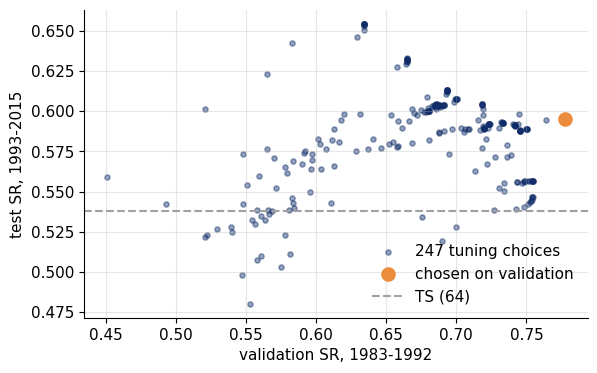

In [24]:
g10 = grid_trees[grid_trees["K"] == 10]
best10 = pick(grid_trees, 10)
ts64_sr = table1.loc["TS (64)", "test SR"]
print("rank correlation of validation and test SR:", round(g10["valid_SR"].corr(g10["test_SR"], method="spearman"), 2))
print("share of choices with test SR above TS (64):", round((g10["test_SR"] > ts64_sr).mean(), 2))
print("chosen point: validation", round(best10["valid_SR"], 3), "-> test", round(best10["test_SR"], 3))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(g10["valid_SR"], g10["test_SR"], s=14, color=NAVY, alpha=0.45, label="247 tuning choices")
ax.scatter(best10["valid_SR"], best10["test_SR"], s=90, color=ORANGE, zorder=3, label="chosen on validation")
ax.axhline(ts64_sr, color=GREY, ls="--", label="TS (64)")
ax.set_xlabel("validation SR, 1983-1992")
ax.set_ylabel("test SR, 1993-2015")
ax.legend(frameon=False, loc="lower right")
fig.savefig(FIG / "overfitting.png")
plt.show()

The validation sample hardly ranks the tuning choices, and the chosen point loses almost 0.2 of Sharpe ratio between validation and test. Still, almost every choice beats TS (64), so the ranking does not depend on a lucky choice of the shrinkage.

## 12. Conclusion

- Our Python version gives exactly the authors' portfolios and the authors' results on their demo setting.
- On the public data AP-Trees (10) reach a test Sharpe ratio of 0.60 against 0.54 for TS (64); FF5 explains 14% of the AP-Tree cross-section and 88% of TS (64). The ranking of the paper holds, the levels are a bit lower because of the noise in the data.
- Interaction nodes are the main source of the result.
- The advantage over good triple sorts is not statistically significant in this one cross-section.

**Limitations:** one cross-section instead of 36; noisy public data; the sample ends in 2015; no trading costs; tuning on a single validation window.